# Asian monsoon flood risk — Exploratory Data Analysis.

**Project objective:** Visualise Monsoon flood frequencies & analyse the correlation between variables and monsoon floods by region.

## 1. Importing libraries & loading data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv("./data/Asian_Monsoon_Flood_Risk_Index.csv")

## 2. Dataset overview

In [2]:
print(f"The dataset has {df.shape[0]} rows, and {df.shape[1]} columns.\n")
print(f"{df.info()}\n")
df.head()

The dataset has 15000 rows, and 9 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Region_ID                  15000 non-null  object 
 1   Monsoon_Intensity_Index    15000 non-null  float64
 2   Topographic_Wetness_Index  15000 non-null  float64
 3   River_Discharge_Rate_CMS   15000 non-null  float64
 4   Deforestation_Rate_Pct     15000 non-null  float64
 5   Urban_Impervious_Pct       15000 non-null  float64
 6   Soil_Moisture_Anomaly      15000 non-null  float64
 7   Flood_Probability          15000 non-null  float64
 8   Flood_Target_Binary        15000 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.0+ MB
None



,Region_ID,Monsoon_Intensity_Index,Topographic_Wetness_Index,River_Discharge_Rate_CMS,Deforestation_Rate_Pct,Urban_Impervious_Pct,Soil_Moisture_Anomaly,Flood_Probability,Flood_Target_Binary
0,Chao_Phraya_TH,74.362844,16.449025,1564.361885,27.566675,16.678039,0.658005,0.603003,0
1,Red_River_VN,57.222951,10.753842,205.219016,35.166157,34.865899,0.358294,0.411600,0
2,Mekong_Delta_VN,45.945754,16.092284,1109.951968,11.538884,35.505539,0.734650,0.541335,0
3,Red_River_VN,62.301348,11.934957,279.376150,14.406374,53.279847,0.873312,0.581188,0
4,Red_River_VN,83.526681,14.355790,4054.892388,76.178339,17.206297,0.428771,0.538685,0


In [27]:
df.columns

Index(['Region_ID', 'Monsoon_Intensity_Index', 'Topographic_Wetness_Index',
       'River_Discharge_Rate_CMS', 'Deforestation_Rate_Pct',
       'Urban_Impervious_Pct', 'Soil_Moisture_Anomaly', 'Flood_Probability',
       'Flood_Target_Binary'],
      dtype='object')

In [18]:
# Are there any missing and duplicated values?
print(f"Missing values: \n{df.isnull().sum()}\n")
print(f"There are {df.duplicated().sum()} duplicated values.")

Missing values: 
Region_ID                    0
Monsoon_Intensity_Index      0
Topographic_Wetness_Index    0
River_Discharge_Rate_CMS     0
Deforestation_Rate_Pct       0
Urban_Impervious_Pct         0
Soil_Moisture_Anomaly        0
Flood_Probability            0
Flood_Target_Binary          0
dtype: int64

There are 0 duplicated values.


In [24]:
# Summary stats and whether there are erroneous data-entry instances.
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region_ID,15000,6,Red_River_VN,2571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monsoon_Intensity_Index,15000.0,NaN,NaN,NaN,67.923181,13.722267,15.0,58.443818,67.954315,77.340699,100.0
Topographic_Wetness_Index,15000.0,NaN,NaN,NaN,12.500639,3.229681,2.0,10.335823,12.492984,14.666124,25.0
River_Discharge_Rate_CMS,15000.0,NaN,NaN,NaN,2621.895219,2561.67134,150.0,768.560404,1815.906136,3675.846978,23821.052769
Deforestation_Rate_Pct,15000.0,NaN,NaN,NaN,28.573616,15.982751,0.133882,16.026379,26.529559,38.786566,89.779539
Urban_Impervious_Pct,15000.0,NaN,NaN,NaN,33.239457,17.764936,0.430283,19.26646,31.256966,45.354716,94.160845
Soil_Moisture_Anomaly,15000.0,NaN,NaN,NaN,0.453093,0.197002,0.0,0.316198,0.451757,0.586435,1.0
Flood_Probability,15000.0,NaN,NaN,NaN,0.497896,0.082825,0.204166,0.441699,0.49764,0.554171,0.820825
Flood_Target_Binary,15000.0,NaN,NaN,NaN,0.0726,0.259487,0.0,0.0,0.0,0.0,1.0


## 3. Exploratory Data Analysis.

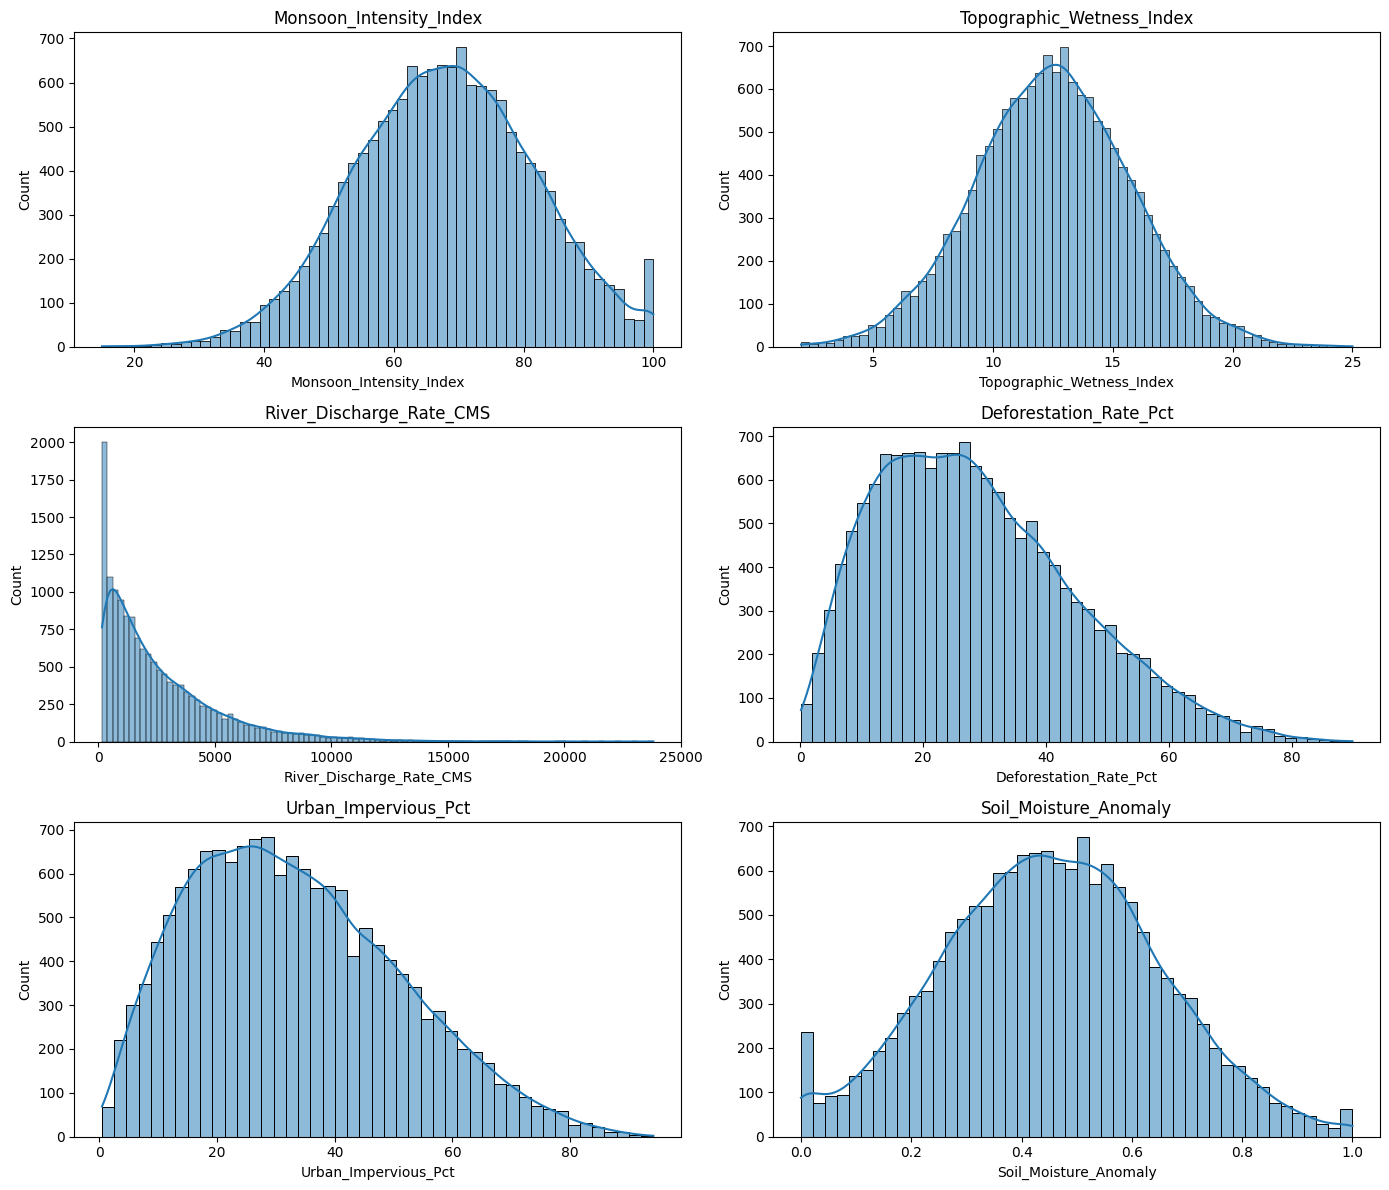

In [244]:
#Visualising the distribution of the numeric values
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes = axes.flatten() #Makes it easier to iterate over all the subplots
features_1 = ['Monsoon_Intensity_Index', 'Topographic_Wetness_Index',
       'River_Discharge_Rate_CMS', 'Deforestation_Rate_Pct',
       'Urban_Impervious_Pct', 'Soil_Moisture_Anomaly']

#Plotting the graphs
for ax, col in zip(axes, features_1):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

#Displaying the visualisations
plt.tight_layout()
plt.show()

#### Distribution of urban impervious percentage by region id

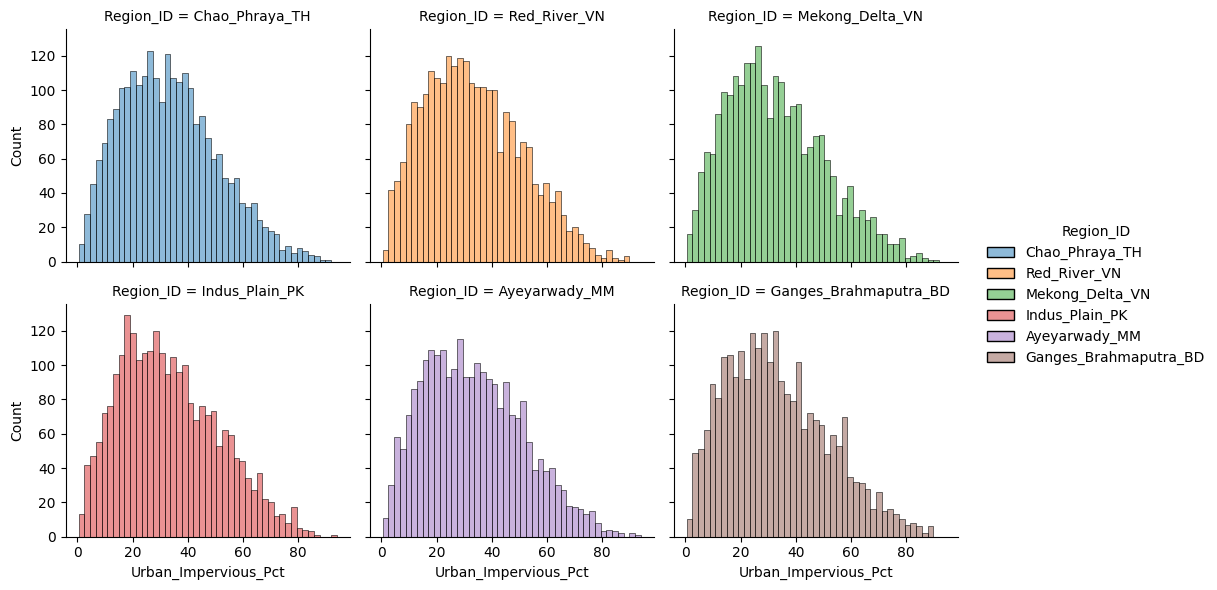

In [9]:
sns.displot(data=df, x="Urban_Impervious_Pct", hue="Region_ID", col="Region_ID", col_wrap=3, height=3, aspect=1.1)

plt.suptitle("")
plt.show()

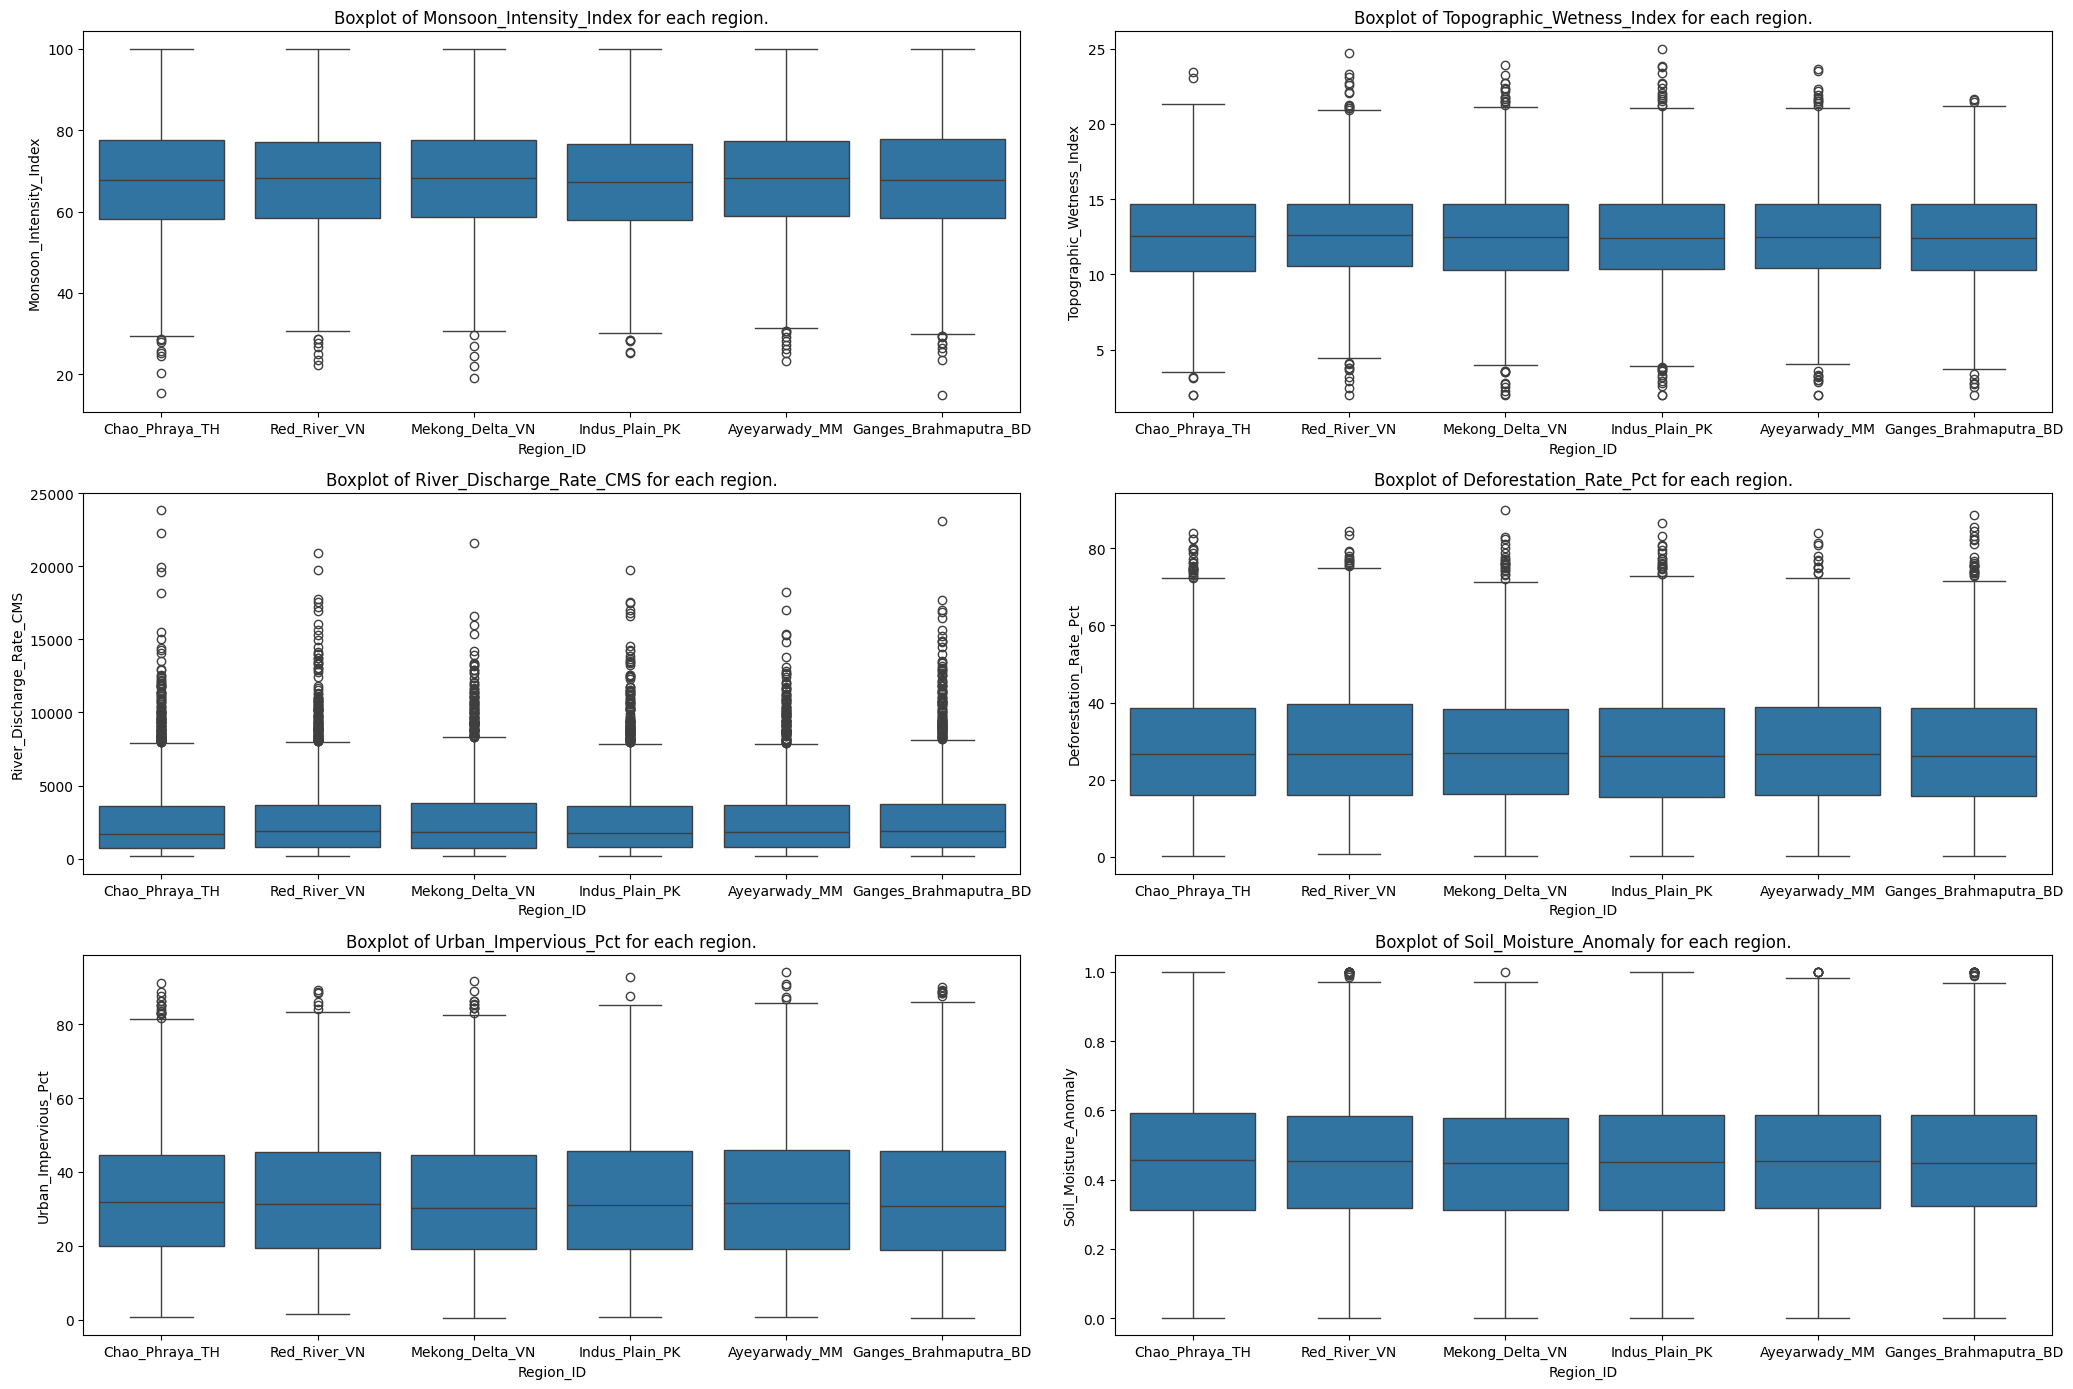

In [245]:
# Boxplots for monsoon intensity by region.

fig, axes = plt.subplots(3, 2, figsize=(21, 14))

axes = axes.flatten()

#Plotting the boxplots
for ax, col in zip(axes, features_1):
    sns.boxplot(x="Region_ID", y=df[col], data=df, ax=ax)
    ax.set_title(f"Boxplot of {col} for each region.")

plt.tight_layout()
plt.show()

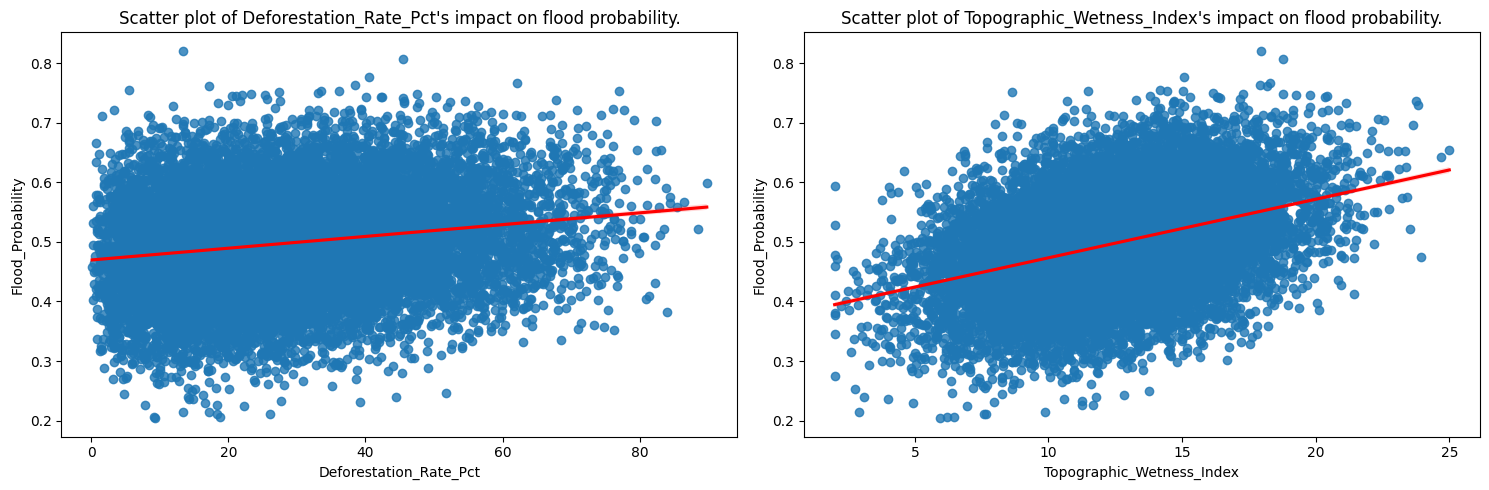

The pearson correlation coefficient between flood probability and deforestation rate pct is: 0.19
The pearson correlation coefficient between flood probability and topographic wetness index is: 0.38


In [143]:
#Influence of Deforestation_Rate_Pct and Topographic_Wetness_Index on Flood_probability
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#axes = axes.flatten()

features = ["Deforestation_Rate_Pct", "Topographic_Wetness_Index"]

for ax, col in zip(axes, features):
    sns.regplot(x=df[col], y="Flood_Probability", line_kws={"color":"red"}, data=df, ax=ax)
    ax.set_title(f"Scatter plot of {col}'s impact on flood probability.")
    
plt.tight_layout()
plt.show()

print(f"The pearson correlation coefficient between flood probability and deforestation rate pct is: {df["Flood_Probability"].corr(df["Deforestation_Rate_Pct"]).round(2)}")
print(f"The pearson correlation coefficient between flood probability and topographic wetness index is: {df["Flood_Probability"].corr(df["Topographic_Wetness_Index"]).round(2)}")

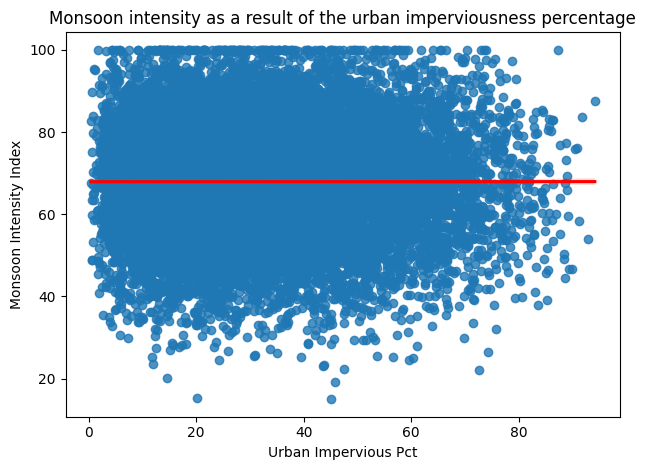

The urban imperviousness has no considerable relationship with the intensity of monsoons since the correlation coeffiecient is: 0.0


In [226]:
# Visualising the correlation between monsoon intensity index as a result of the urban imperviousness percentage

fig, ax = plt.subplots()

sns.regplot(x="Urban_Impervious_Pct", y="Monsoon_Intensity_Index", line_kws={"color":"red"}, data=df, ax=ax)
ax.set_title("Monsoon intensity as a result of the urban imperviousness percentage")
ax.set_xlabel("Urban Impervious Pct")
ax.set_ylabel("Monsoon Intensity Index")

plt.tight_layout()
plt.show()

print(f"The urban imperviousness has no considerable relationship with the intensity of monsoons since the correlation coeffiecient is: {df["Urban_Impervious_Pct"].corr(df["Monsoon_Intensity_Index"]).round(3)}")

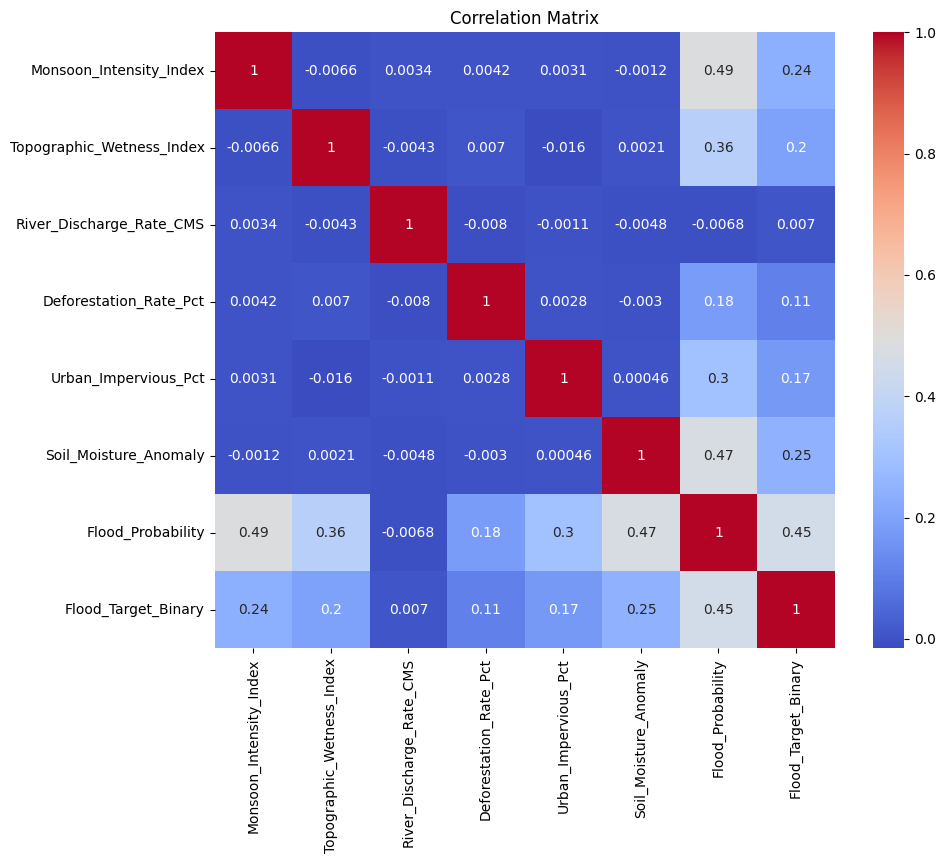

Flood_Probability            1.000000
Monsoon_Intensity_Index      0.486655
Soil_Moisture_Anomaly        0.470034
Flood_Target_Binary          0.449430
Topographic_Wetness_Index    0.363802
Urban_Impervious_Pct         0.301325
Deforestation_Rate_Pct       0.179735
River_Discharge_Rate_CMS    -0.006827
Name: Flood_Probability, dtype: float64

In [247]:
# Correlation matrix
plt.figure(figsize=(10, 8))
corr = df[features_1 + ['Flood_Probability', 'Flood_Target_Binary']].corr(method='spearman') #Using spearman's method because of the presence of an 
#ordinal variable, flood target binary, non-continouous value in the matrix.

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

corr['Flood_Probability'].sort_values(ascending=False)

In [248]:
#Flood rate by different regions
regions= df.groupby('Region_ID')['Flood_Target_Binary'].agg(['mean','count']).sort_values('mean',ascending=False)
regions.columns = ["flood_rate", "records"]
regions

,flood_rate,records
Region_ID,,
Red_River_VN,0.080513,2571
Chao_Phraya_TH,0.075170,2501
Mekong_Delta_VN,0.072195,2424
Indus_Plain_PK,0.069988,2529
Ayeyarwady_MM,0.069246,2455
Ganges_Brahmaputra_BD,0.068254,2520


Text(0.5, 0.98, ' ')

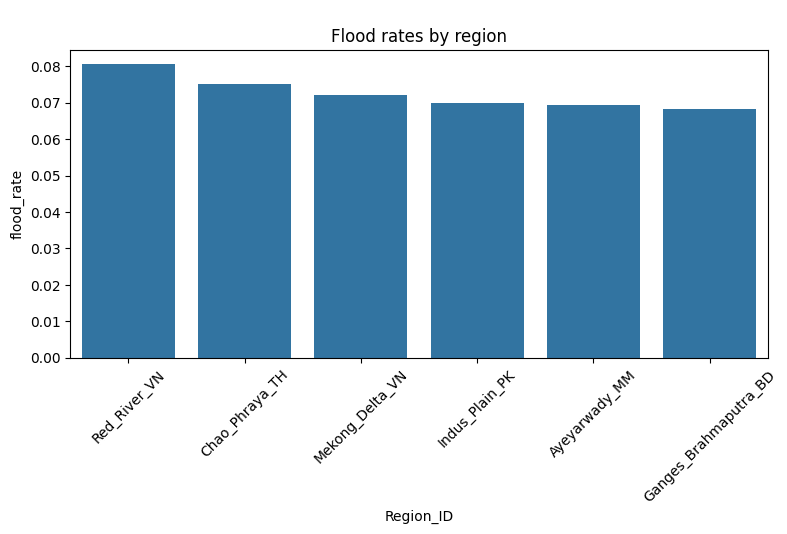

In [250]:
plt.figure(figsize=(9, 4))
sns.barplot(x=regions.index, y=regions['flood_rate'])
plt.title("Flood rates by region")
plt.xticks(rotation=45)
plt.suptitle(" ")

## 4. Multiple-regression analysis.

In [251]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Flood_Probability ~ Deforestation_Rate_Pct + Topographic_Wetness_Index"
    "+ C(Region_ID) + Flood_Target_Binary", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Flood_Probability   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     1156.
Date:                Sat, 25 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:52:37   Log-Likelihood:                 19685.
No. Observations:               15000   AIC:                        -3.935e+04
Df Residuals:                   14991   BIC:                        -3.928e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------